In [7]:
# Import

from skimage import io, measure
from glob import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.ticker import MultipleLocator

In [ ]:
# Data loading --> Choosing a folder

# Path to the microscopy dataset on network drive
# The 'r' prefix creates a raw string, preventing backslashes from being interpreted
# as escape characters (e.g., \n would be newline without 'r')
folder_path = r'Y:\Group Members\Valentin Aubry\01_Data\AP470_U2OS_gH2AX(488)_53BP1(568)_EdU(647)_20x_002\data'


# Validate that the folder exists and contains files
if os.path.isdir(folder_path) == True:
    print("Folder Path exists")

    # Get list of all items (files and subdirectories) in the folder
    dir = os.listdir(folder_path)
    
    # Check if folder has any contents
    if len(dir) == 0:
        print("Empty directory")
    else:
        print("Not empty directory")
else:
    print("Folder path not found")
    # NOTE: Consider raising an error here to stop execution early
    # raise FileNotFoundError(f"Folder not found: {folder_path}")

Folder Path exists
Not empty directory


In [ ]:
# Data Loading --> Loading folder content

# Find all Cellpose segmentation output files for DAPI channel
# glob() returns a list of file paths matching the pattern
# Pattern: *DAPI SEM_seg.npy matches files like "001_DAPI SEM_seg.npy"
DAPI_mask_data = glob(os.path.join(folder_path, '*DAPI SEM_seg.npy'))

# Sort alphabetically/numerically to ensure consistent processing order
# Important for reproducibility and matching with other data
DAPI_mask_data.sort()

# Display all found mask files for verification
for mask_path in DAPI_mask_data:
    # os.path.basename() extracts just the filename from the full path
    # e.g., "Y:\...\001_DAPI SEM_seg.npy" -> "001_DAPI SEM_seg.npy"
    print(os.path.basename(mask_path))

ATR1_24h--W00032--P00001--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00002--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00003--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00004--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00005--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00006--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00007--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00008--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00009--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00010--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00011--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00012--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00013--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00014--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00015--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00016--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00017--Z00000--T00000--DAPI SEM_seg.n

In [ ]:
# Cellpose DAPI Mask Cleanup - Step 1: Border Removal
# Nuclei touching image edges are often partial/incomplete and should be excluded
# from analysis to avoid biased measurements

start_time = time.time()

# Lists to track nuclei counts before and after border removal
all_areas = []           # Original nuclei areas (including border-touching)
all_areas_noborder = []  # Nuclei areas after removing border-touching ones

for i in range(len(DAPI_mask_data)):
    # Load the segmentation mask file
    # allow_pickle=True is required because Cellpose saves masks as Python dictionaries
    loaded_data = np.load(DAPI_mask_data[i], allow_pickle=True)
    
    # Handle two possible file formats:
    # 1. Cellpose output: dictionary with 'masks', 'flows', etc. keys
    # 2. Already processed: plain numpy array (from previous cleanup runs)
    try:
        # Attempt to load as dictionary (standard Cellpose format)
        mask_dict = loaded_data.item()  # .item() extracts dict from 0-d array
        mask = mask_dict['masks']
    except (ValueError, AttributeError):
        # If not a dictionary, assume it's already a plain mask array
        mask = loaded_data
    
    # Calculate region properties for all nuclei in the mask
    # regionprops() analyzes each unique label (each nucleus) and returns
    # properties like area, centroid, bounding box, etc.
    props = measure.regionprops(mask)
    areas = [region.area for region in props]
    all_areas.append(areas)
    
    ## Border Removal Logic
    # Create a list to store labels of nuclei that DON'T touch borders
    labels_to_keep = []
    
    for region in props:
        # Get bounding box coordinates for this nucleus
        # bbox = (min_row, min_col, max_row, max_col)
        min_row, min_col, max_row, max_col = region.bbox
        
        # Check if nucleus touches any of the four image borders
        # NOTE: 2048 is hardcoded - assumes 2048x2048 pixel images
        # Consider using mask.shape for flexibility:
        # touches_border = (min_row == 0 or min_col == 0 or
        #                   max_row == mask.shape[0] or max_col == mask.shape[1])
        touches_border = (min_row == 0 or min_col == 0 or 
                          max_row == 2048 or max_col == 2048)
    
        if not touches_border:
            # This nucleus is fully contained within the image - keep it
            labels_to_keep.append(region.label)
    
    # Create a new mask containing only the non-border nuclei
    mask_clean_border = np.zeros_like(mask)  # Start with empty mask (all zeros)
    for label in labels_to_keep:
        # Copy pixels belonging to this nucleus from original to new mask
        # Preserves the original label numbers (will be renumbered in step 2)
        mask_clean_border[mask == label] = label
    
    # Calculate properties for the cleaned mask (for statistics)
    props_no_border = measure.regionprops(mask_clean_border)
    areas = [region.area for region in props_no_border]
    all_areas_noborder.append(areas)
    
    # Save the border-cleaned mask with "_noborder" suffix
    # This preserves the original Cellpose output for reference
    base_name = os.path.basename(DAPI_mask_data[i])
    name_without_ext = os.path.splitext(base_name)[0]  # Remove .npy extension
    np.save(folder_path + '/' + name_without_ext + '_noborder.npy', 
            mask_clean_border, allow_pickle=True)

# Calculate and display runtime statistics
end_time = time.time()
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

print(f"Border removal complete!")
print(f"Total runtime: {minutes} minutes and {seconds:.2f} seconds")
print(f"\nTotal nuclei counts:")
print(f"  Original: {sum(len(a) for a in all_areas)}")
print(f"  After border removal: {sum(len(a) for a in all_areas_noborder)}")

'''
Performance benchmark:
735 Pictures: 18min 19sec
Approximately 1.5 seconds per image
'''

Border removal complete!
Total runtime: 18 minutes and 19.08 seconds

Total nuclei counts:
  Original: 51109
  After border removal: 45660


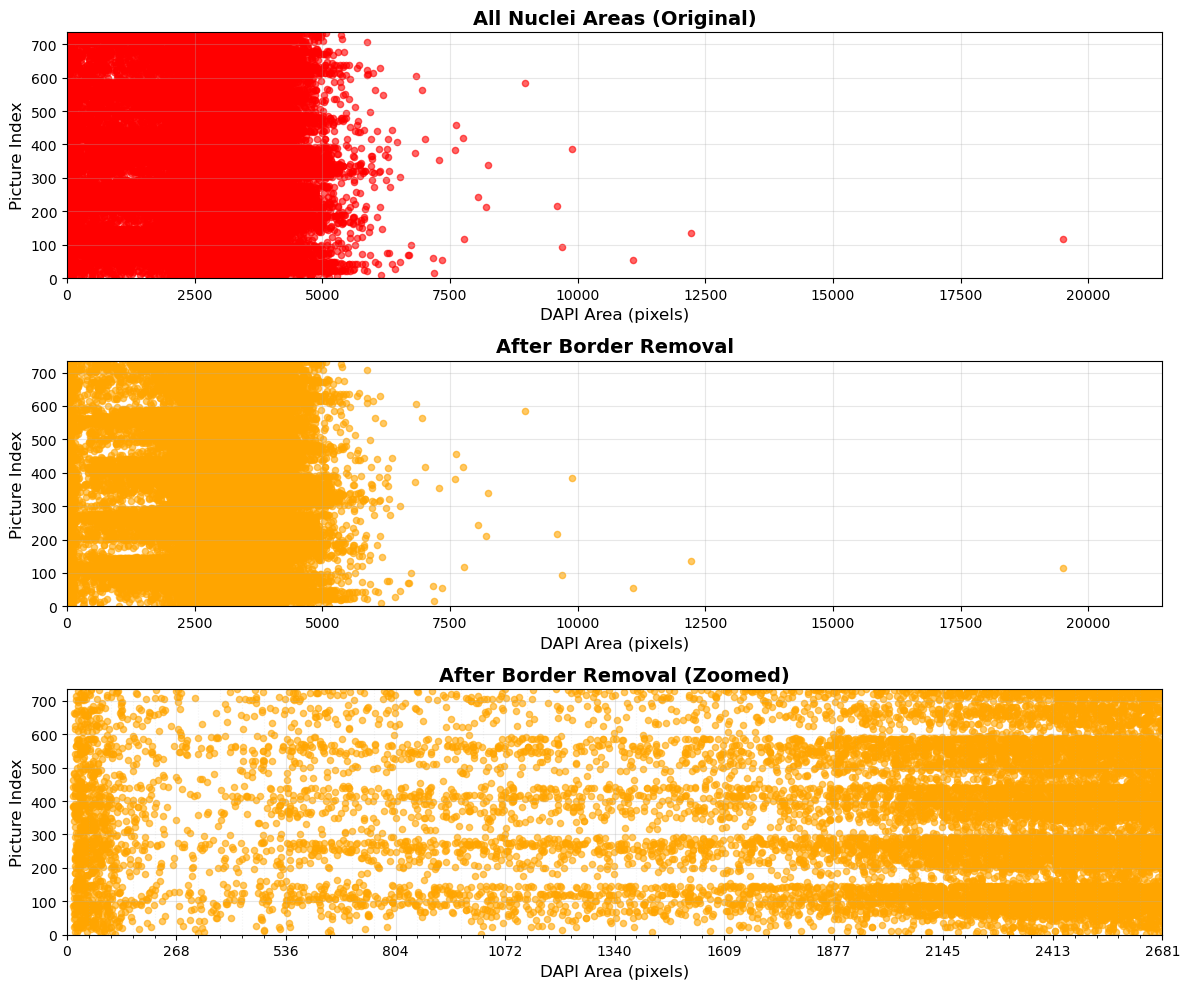


Size distribution statistics (after border removal):
  Min: 15 pixels
  25th percentile: 2512 pixels
  Median: 3079 pixels
  75th percentile: 3642 pixels
  Max: 19498 pixels


In [ ]:
# Display size distribution after border removal
# This visualization helps determine an appropriate size threshold for the next step

# Create a figure with 3 vertically stacked subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Combine all area measurements to determine consistent axis limits
all_combined = []
for areas in all_areas + all_areas_noborder:
    all_combined.extend(areas)  # Flatten nested lists into one list

# Set axis limits for consistent comparison across plots
y_max = len(DAPI_mask_data) + 0.5  # One row per image, plus padding
x_min = 0
x_max = max(all_combined) * 1.1 if all_combined else 5000  # 10% padding on right

# ========== Plot 1: Original nuclei (before any cleanup) ==========
for i, areas in enumerate(all_areas):
    # Scatter plot: x = area, y = image index
    # Each dot represents one nucleus; dots at same y are from same image
    axes[0].scatter(areas, [i+1]*len(areas), alpha=0.6, s=20, color='red')
axes[0].set_xlabel('DAPI Area (pixels)', fontsize=12)
axes[0].set_ylabel('Picture Index', fontsize=12)
axes[0].set_title('All Nuclei Areas (Original)', fontsize=14, fontweight='bold')
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(0, y_max)
axes[0].grid(True, alpha=0.3)

# ========== Plot 2: After border removal ==========
for i, areas in enumerate(all_areas_noborder):
    axes[1].scatter(areas, [i+1]*len(areas), alpha=0.6, s=20, color='orange')
axes[1].set_xlabel('DAPI Area (pixels)', fontsize=12)
axes[1].set_ylabel('Picture Index', fontsize=12)
axes[1].set_title('After Border Removal', fontsize=14, fontweight='bold')
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(0, y_max)
axes[1].grid(True, alpha=0.3)

# ========== Plot 3: Zoomed view to see small nuclei distribution ==========
# Zooming in helps identify where to set the minimum size threshold
zoom_max = 2500  # Can be changed, based on the data
for i, areas in enumerate(all_areas_noborder):
    axes[2].scatter(areas, [i+1]*len(areas), alpha=0.6, s=20, color='orange')
axes[2].set_xlabel('DAPI Area (pixels)', fontsize=12)
axes[2].set_ylabel('Picture Index', fontsize=12)
axes[2].set_title('After Border Removal (Zoomed)', fontsize=14, fontweight='bold')
axes[2].set_xlim(x_min, zoom_max)
axes[2].set_ylim(0, y_max)

# Add detailed grid lines for easier threshold selection
major_tick_spacing = zoom_max / 10   # 10 major gridlines
minor_tick_spacing = major_tick_spacing / 5  # 5 minor gridlines between majors
axes[2].xaxis.set_major_locator(MultipleLocator(major_tick_spacing))
axes[2].xaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))
axes[2].grid(True, alpha=0.3, which='major')
axes[2].grid(True, alpha=0.15, which='minor', linestyle=':')

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()

# Print statistical summary to help choose threshold
# Look for a natural gap in the distribution between debris and real nuclei
print("\nSize distribution statistics (after border removal):")
all_sizes = [area for areas in all_areas_noborder for area in areas]  # Flatten
print(f"  Min: {min(all_sizes):.0f} pixels")
print(f"  25th percentile: {np.percentile(all_sizes, 25):.0f} pixels")
print(f"  Median: {np.percentile(all_sizes, 50):.0f} pixels")
print(f"  75th percentile: {np.percentile(all_sizes, 75):.0f} pixels")
print(f"  Max: {max(all_sizes):.0f} pixels")

In [ ]:
# Cellpose DAPI Mask Cleanup - Step 2: Size Threshold
# Remove small fragments that are likely debris, segmentation artifacts, or apoptotic bodies
# rather than real nuclei

start_time = time.time()

# Reset tracking lists for this step
all_areas_noborder = []  # Areas from border-cleaned masks (input to this step)
all_areas_clean = []     # Areas after size filtering (output of this step)

# Minimum nucleus size threshold in pixels
# Adjust based on the distribution visualized in Cell 4
# Objects smaller than this are considered debris/artifacts
threshold = 500  # <-- TUNE THIS VALUE based on your data

for i in range(len(DAPI_mask_data)):
    # Construct path to the border-cleaned mask from Step 1
    base_name = os.path.basename(DAPI_mask_data[i])
    name_without_ext = os.path.splitext(base_name)[0]
    mask_clean_border = np.load(folder_path + '/' + name_without_ext + '_noborder.npy', 
                                 allow_pickle=True)
    
    # Get properties from the border-cleaned mask
    props_no_border = measure.regionprops(mask_clean_border)
    areas = [region.area for region in props_no_border]
    all_areas_noborder.append(areas)
    
    ## Size threshold filtering
    # Keep only nuclei that meet the minimum size requirement
    labels_final = []
    for region in props_no_border:
        if region.area >= threshold:
            labels_final.append(region.label)
    
    # Create mask containing only size-filtered nuclei
    clean_mask = np.zeros_like(mask_clean_border)
    for label in labels_final:
        clean_mask[mask_clean_border == label] = label
 
    ## Renumber labels to be sequential (1, 2, 3, ...) instead of sparse (3, 7, 12, ...)
    # This is important for downstream analysis tools that expect consecutive labels
    clean_mask_renumbered = np.zeros_like(clean_mask)
    
    # Get all unique labels (each represents one nucleus)
    unique_labels = np.unique(clean_mask)
    # Remove background label (0) from the list
    unique_labels = unique_labels[unique_labels != 0]
    
    # Map old labels to new sequential labels
    # Example: if remaining labels are [3, 7, 12, 15], remap to [1, 2, 3, 4]
    for new_label, old_label in enumerate(unique_labels, start=1):
        clean_mask_renumbered[clean_mask == old_label] = new_label
    
    # Calculate final properties for statistics
    props_clean = measure.regionprops(clean_mask_renumbered)
    areas = [region.area for region in props_clean]
    all_areas_clean.append(areas)
    
    # Save the fully cleaned mask
    # NOTE: This OVERWRITES the original Cellpose output file
    # Consider using a different suffix (e.g., "_clean.npy") to preserve original
    np.save(folder_path + '/' + base_name, clean_mask_renumbered, allow_pickle=True)

# Display runtime and cleanup statistics
end_time = time.time()
elapsed_time = end_time - start_time
minutes = int(elapsed_time // 60)
seconds = elapsed_time % 60

print(f"Size threshold cleanup complete!")
print(f"Total runtime: {minutes} minutes and {seconds:.2f} seconds")
print(f"\nTotal nuclei counts:")
print(f"  After border removal: {sum(len(a) for a in all_areas_noborder)}")
print(f"  After cleanup: {sum(len(a) for a in all_areas_clean)}")
print(f"  Removed by size threshold: {sum(len(a) for a in all_areas_noborder) - sum(len(a) for a in all_areas_clean)}")

Size threshold cleanup complete!
Total runtime: 8 minutes and 41.48 seconds

Total nuclei counts:
  After border removal: 45660
  After cleanup: 44303
  Removed by size threshold: 1357


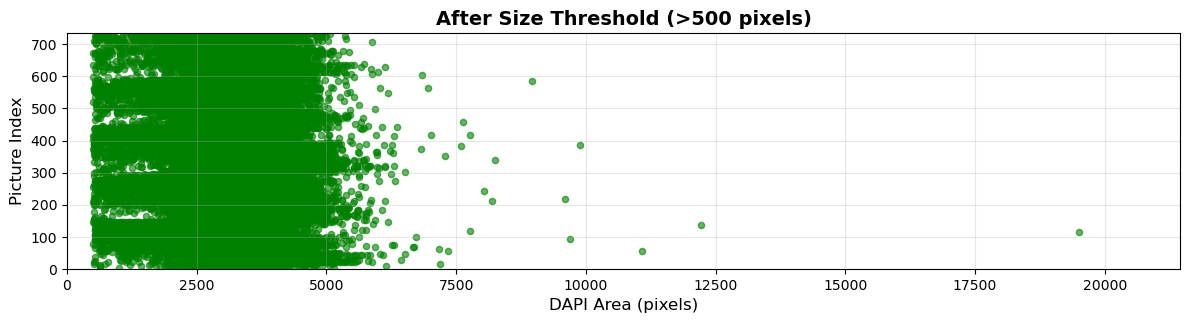

In [ ]:
#---------Display------------#
# Visualize the final cleaned nuclei distribution

# Combine all area data for consistent axis scaling
all_combined = []
for areas in all_areas + all_areas_noborder + all_areas_clean:
    all_combined.extend(areas)

# Calculate axis limits
y_max = len(DAPI_mask_data) + 0.5  # One row per image
x_min = 0
x_max = max(all_combined) * 1.1 if all_combined else 5000  # 10% padding

# Create single plot showing final cleaned data
fig, axes = plt.subplots(1, 1, figsize=(12, 3.33333))

# Scatter plot of final nuclei areas
# Green color indicates these are the final, cleaned nuclei ready for analysis
for i, areas in enumerate(all_areas_clean):
    axes.scatter(areas, [i+1]*len(areas), alpha=0.6, s=20, color='green')

axes.set_xlabel('DAPI Area (pixels)', fontsize=12)
axes.set_ylabel('Picture Index', fontsize=12)
# Include threshold value in title for documentation
axes.set_title('After Size Threshold (>' + str(threshold) + ' pixels)', 
               fontsize=14, fontweight='bold')
axes.set_xlim(x_min, x_max)
axes.set_ylim(0, y_max)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# At this point, all nuclei shown are:
# 1. Fully contained within the image (not touching borders)
# 2. Above the minimum size threshold
# Ready for downstream analysis (intensity measurements, counting, etc.)